TASK 2 - KEY INSIGHTS SUMMARY

1. OVERALL CHURN RATE:
   - 26.5% of customers churned = 1,869 out of 7,043 customers

2. GENDER:
   - Gender has low impact on churn
   - Males and females churn are at similar rates

3. TENURE:
   - Churned customers stay at an average of 18 months
   - Loyal customers stay at an average of 37.6 months
   - New customers are the highest risk group

4. CONTRACT TYPE:
   - Month-to-month =42.7% churn
   - One year = 11.3% churn
   - Two year = 2.8% churn
   - Longer contracts = much lower churn

5. PAYMENT METHOD:
   - Electronic check = 45.3% churn 
   - Credit card = 15.2% churn
   - Bank transfer = 16.7% churn
   - Auto-payment customers are more loyal.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Cleaned_Churn_Data.csv')

print("Data loaded")
print("Shape:", df.shape)
df.head()


Data loaded
Shape: (7043, 25)


,customerID,SeniorCitizen,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes
0,7590-VHVEG,0,1,No phone service,No,Yes,No,No,No,No,...,False,True,False,False,False,False,True,False,False,True
1,5575-GNVDE,0,34,No,Yes,No,Yes,No,No,No,...,False,False,True,False,False,True,False,False,True,False
2,3668-QPYBK,0,2,No,Yes,Yes,No,No,No,No,...,False,False,True,False,False,True,False,False,True,True
3,7795-CFOCW,0,45,No phone service,Yes,No,Yes,Yes,No,No,...,False,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,2,No,No,No,No,No,No,No,...,False,True,False,True,False,False,False,False,True,True


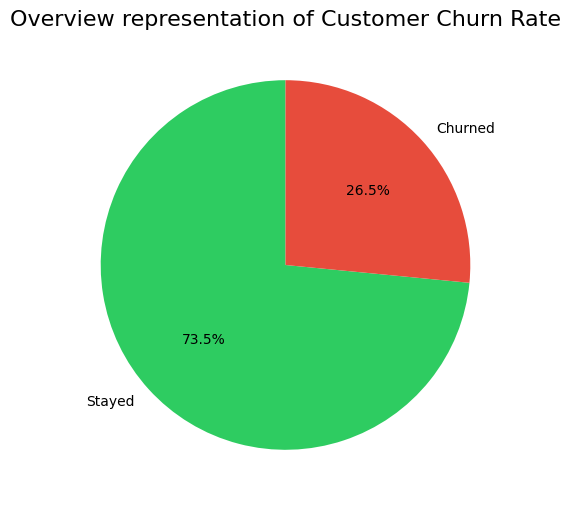

Total customers = 7043
Churned = 1869 ( 26.5%)
Stayed  = 5174 (73.5%)


In [4]:
Churn_counts = df['Churn'].value_counts()
Churn_labels = ['Stayed', 'Churned']
Churn_colors = ['#2ecc61', '#e74c3c']

plt.figure(figsize=(8, 6))
plt.pie(Churn_counts, labels = Churn_labels, colors = Churn_colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Overview representation of Customer Churn Rate', fontsize = 16)
plt.show()

total = len(df)
churned = df['Churn'].sum()
print(f"Total customers = {total}")
print(f"Churned = {churned} ({churned/total*100: .1f}%)")
print(f"Stayed  = {total-churned} ({(total-churned)/total*100:.1f}%)")

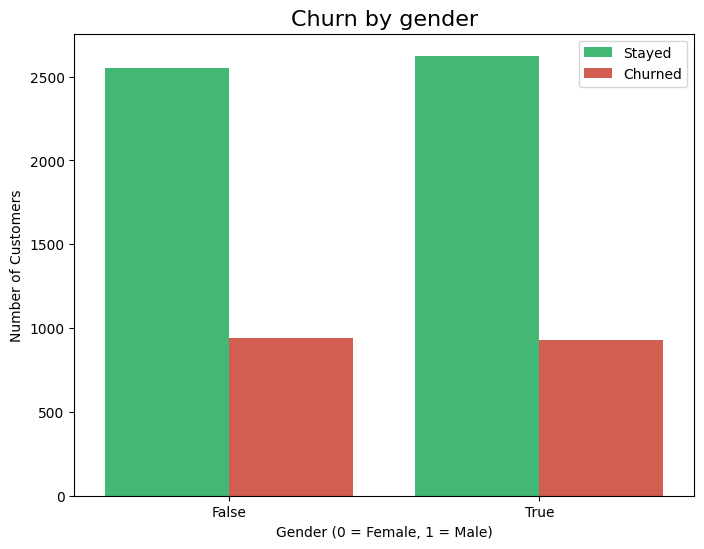

Churn by Gender:
gender_Male  Churn
False        0        2549
             1         939
True         0        2625
             1         930
Name: count, dtype: int64


In [8]:
plt.figure(figsize = (8, 6))
sns.countplot(data = df, x ='gender_Male', hue = 'Churn', palette = ['#2ecc71', '#e74c3c'])
plt.title('Churn by gender', fontsize = 16)
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.show()

print("Churn by Gender:")
print(df.groupby('gender_Male')['Churn'].value_counts())


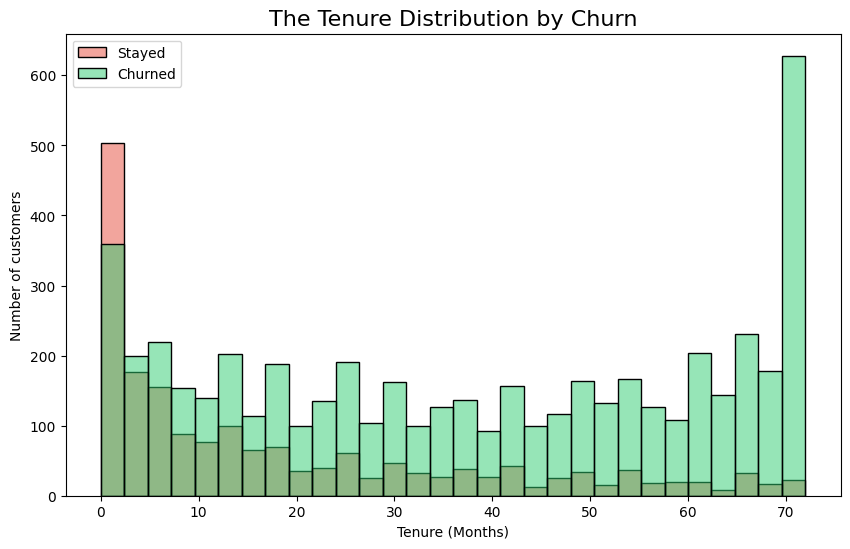

Average tenure for churned customers: 18.0 months
Average tenure for stayed customers: 37.6 months


In [11]:
plt.figure(figsize = (10, 6))
sns.histplot(data = df, x = 'tenure', hue = 'Churn', bins = 30, palette = ['#2ecc71', '#e74c3c'])
plt.title('The Tenure Distribution by Churn', fontsize = 16)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of customers')
plt.legend(labels = ['Stayed', 'Churned'])
plt.show()

print("Average tenure for churned customers:", round(df[df['Churn'] == 1]['tenure'].mean(), 1), "months")
print("Average tenure for stayed customers:", round(df[df['Churn'] == 0]['tenure'].mean(), 1), "months")


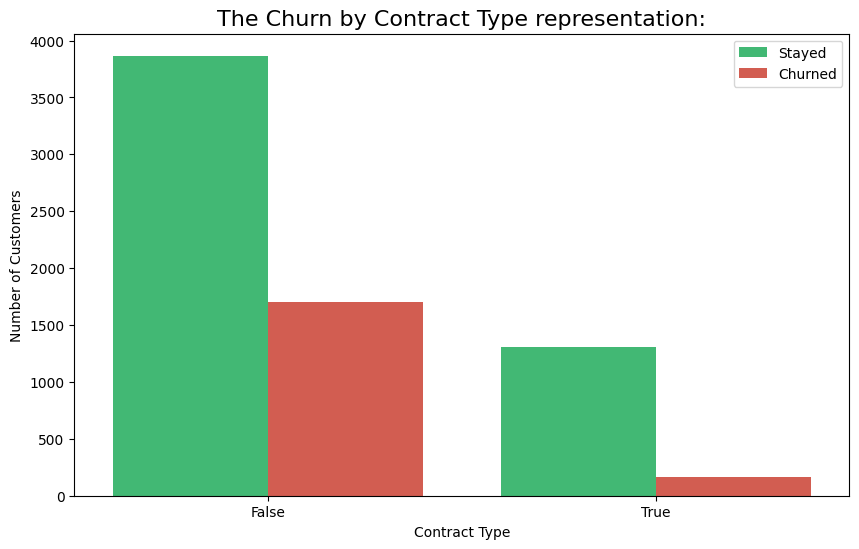

Churn rate by Contract Type:
Contract_One year  Contract_Two year
False              False                42.7
                   True                  2.8
True               False                11.3
Name: Churn, dtype: float64


In [13]:
plt.figure(figsize = (10, 6))
sns.countplot(data = df, x = 'Contract_One year', hue = 'Churn', palette = ['#2ecc71', '#e74c3c'])

plt.title('The Churn by Contract Type representation:', fontsize = 16)
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(labels = ['Stayed', 'Churned'])
plt.show()

print("Churn rate by Contract Type:")
contract_churn = df.groupby(['Contract_One year', 'Contract_Two year'])['Churn'].mean()*100
print(contract_churn.round(1))

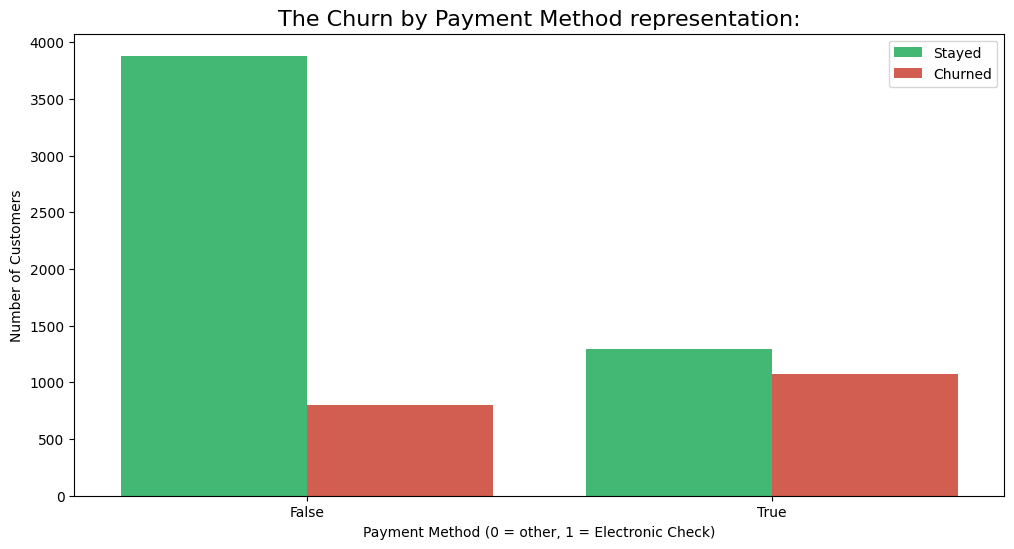

Churn rate by Payment Method:
Credit card (automatic): 15.2%
Electronic check: 45.3%
Mailed check: 19.1%
Bank transfer (automatic): 16.7%


In [17]:
plt.figure(figsize = (12, 6))
sns.countplot(data = df, x = 'PaymentMethod_Electronic check', hue = 'Churn', palette = ['#2ecc71', '#e74c3c'])

plt.title('The Churn by Payment Method representation:', fontsize = 16)
plt.xlabel('Payment Method (0 = other, 1 = Electronic Check)')
plt.ylabel('Number of Customers')
plt.legend(labels = ['Stayed', 'Churned'])
plt.show()

print("Churn rate by Payment Method:")
payment_cols = ['PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
for col in payment_cols:
    method_name = col.replace('PaymentMethod_', '')
    churn_rate = df[df[col] == 1]['Churn'].mean()*100
    print(f"{method_name}: {churn_rate:.1f}%")

bank_mask = ((df['PaymentMethod_Credit card (automatic)'] == 0) &
             (df['PaymentMethod_Electronic check'] == 0) &
             (df['PaymentMethod_Mailed check'] == 0))
print(f"Bank transfer (automatic): {d[bank_mask]['Churn'].mean()*100:.1f}%")